In [3]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(repo_id="openvision/yolo26-x-pose", filename="model.pt")


/Users/hyeon/Library/Python/3.13/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO(model_path)
img = "/Users/hyeon/SeSAC_Project/Sapiens2/inputs/videos/test1/frames/00000001.png"
# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(img)

# Run inference with the YOLO26x-pose model on the image
results = model.predict(image)



0: 640x384 1 person, 168.2ms
Speed: 2.0ms preprocess, 168.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)


In [12]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: ultralytics.engine.results.Keypoints object
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[  1, 112, 111],
         [  2, 113, 112],
         [ 16, 116, 116],
         ...,
         [  9,  70,  88],
         [ 11,  80,  96],
         [ 15,  83, 100]],
 
        [[  0, 109, 108],
         [  0, 111, 110],
         [ 13, 113, 113],
         ...,
         [ 32,  94, 111],
         [ 33, 102, 118],
         [ 37, 105, 122]],
 
        [[  5, 101, 101],
         [  8, 103, 103],
         [ 20, 107, 108],
         ...,
         [ 35, 109, 125],
         [ 35, 116, 131],
         [ 39, 119, 134]],
 
        ...,
 
        [[151, 147, 145],
         [151, 147, 145],
         [150, 146, 144],
         ...,
         [132, 129, 126],
         [132, 129, 126],
         [132, 129, 126]],
 
        [[151, 147, 145],
         [151, 147, 145],
         [150, 146,

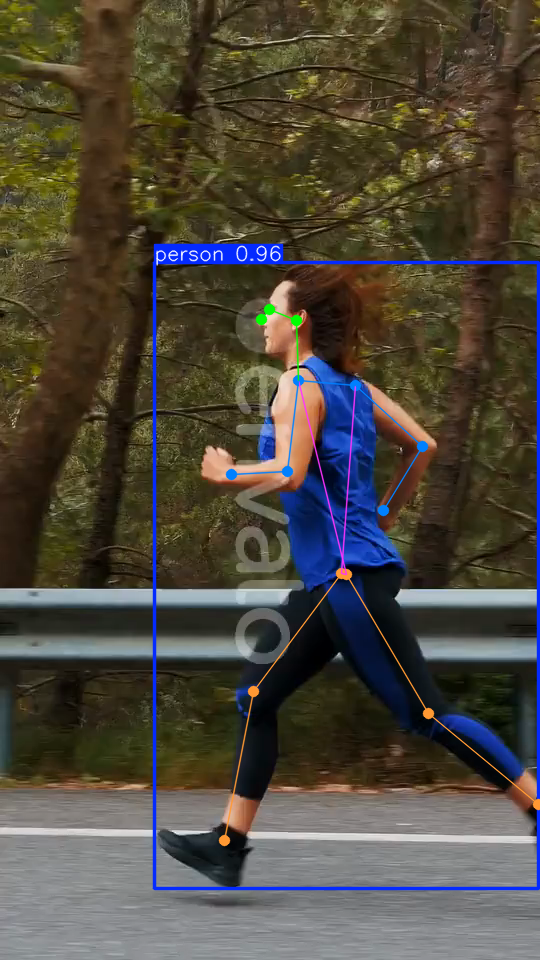

In [13]:
from PIL import Image
from IPython.display import display

annotated = results[0].plot()          # 관절/박스가 그려진 BGR 이미지
display(Image.fromarray(annotated[..., ::-1]))  # RGB로 변환해 표시